# Autoencoder (64x16x64) on Digits Dataset

Training a simple autoencoder to compress 8x8 digit images down to 16 dimensions and reconstruct them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from nn.nn import NeuralNetwork

## Load and prep the data

In [2]:
digits = load_digits()
X = digits.data / 16.0  # scale pixel values to [0, 1] for sigmoid output

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Validation set: {X_val.shape}')

Training set: (1437, 64)
Validation set: (360, 64)


## Build and train the autoencoder

In [3]:
arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'sigmoid'},
    {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'}
]

autoencoder = NeuralNetwork(
    nn_arch=arch,
    lr=1.0,
    seed=42,
    batch_size=64,
    epochs=200,
    loss_function='mean_squared_error'
)

# for an autoencoder, the target is the input itself
train_loss, val_loss = autoencoder.fit(X_train, X_train, X_val, X_val)

## Plot training and validation loss

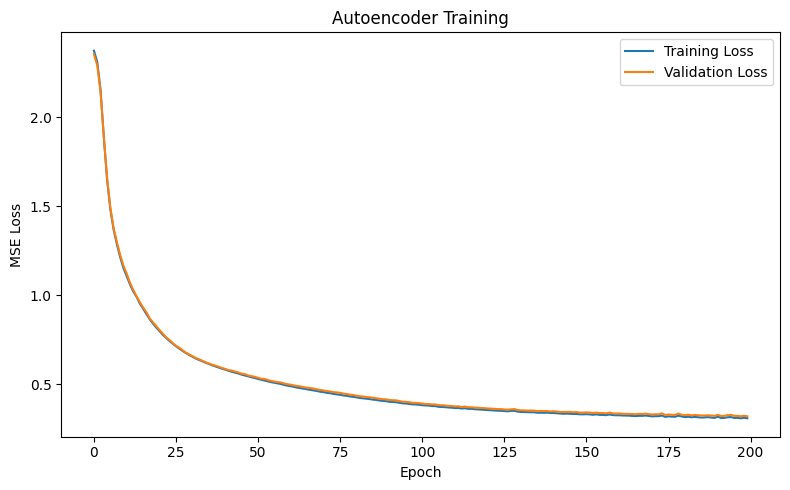

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.tight_layout()
plt.show()

## Reconstruction error on validation set

In [5]:
reconstructed = autoencoder.predict(X_val)  # shape: (64, n_val)
recon_error = np.mean((X_val.T - reconstructed) ** 2)
print(f'Average reconstruction error (MSE) on validation set: {recon_error:.4f}')

Average reconstruction error (MSE) on validation set: 0.0100


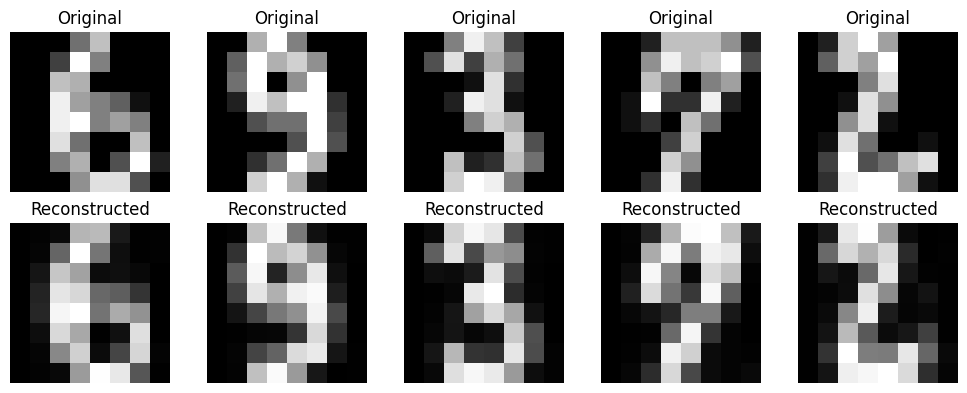

In [6]:
# visualize a few reconstructions
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(X_val[i].reshape(8, 8), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[:, i].reshape(8, 8), cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## Hyperparameter choices

- **Learning rate (1.0):** I tried a few values (0.1, 0.5, 1.0) and 1.0 converged fastest without becoming unstable. Since we're using sigmoid activations and MSE loss the gradients tend to be small, so a larger learning rate helps.
- **Batch size (64):** Seemed like a reasonable middle ground -- small enough for some stochasticity but big enough to get stable gradient estimates.
- **Epochs (200):** I watched the loss curve and it was still dropping slowly around 100, so I went with 200 to let it flatten out.
- **Sigmoid activation:** Used sigmoid for both layers since pixel values are between 0 and 1, and sigmoid naturally outputs in that range.
- **MSE loss:** Natural choice for reconstruction since we want to minimize the pixel-wise difference between input and output.